In [ ]:
# Author: Saiful
# Email: mislam5@nd.edu

In [1]:
# Execute for google colab only
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup For Evaluation

### Imports

In [3]:
!pip install pesq pystoi --quiet

  Preparing metadata (setup.py) ... done


In [4]:
import os
import numpy as np
import librosa
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from pesq import pesq
from pystoi.stoi import stoi
import matplotlib.pyplot as plt
import librosa.display
import pandas as pd
import seaborn as sns

### Model Definition

In [5]:
class DenoisignUNet(nn.Module):

    def __init__(self):
        super().__init__()
        # Add comment

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 32, 3, padding=1), nn.LeakyReLU(0.2)
        )
        self.pool1 = nn.MaxPool2d(kernel_size=(1,2))

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, padding=1), nn.LeakyReLU(0.2)
        )
        self.pool2 = nn.MaxPool2d(kernel_size=(1,2))

        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 3, padding=1), nn.LeakyReLU(0.2),
        )

        self.up2 = nn.Conv2d(128, 64, 1)
        self.dec2 = nn.Sequential(
            nn.Conv2d(64+64, 64, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, padding=1), nn.LeakyReLU(0.2),
        )

        self.up1 = nn.Conv2d(64, 32, 1)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32+32, 32, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 32, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        u2_up = F.interpolate(u2, size=(e2.shape[2], e2.shape[3]), mode='nearest')
        d2 = self.dec2(torch.cat([u2_up, e2], dim=1))

        u1 = self.up1(d2)
        u1_up = F.interpolate(u1, size=(e1.shape[2], e1.shape[3]), mode='nearest')
        d1 = self.dec1(torch.cat([u1_up, e1], dim=1))
        return d1

### Configuration

In [6]:
class Cfg:
    sr = 16000
    n_fft = 512
    hop = 128
    win = 512
    seg_len = 32000  # 2 s
    batch = 16

### Dataset Class

In [7]:
import json
import glob, pandas as pd, os, random, pathlib

def stft2logmag(y, cfg):
    D = librosa.stft(y, n_fft=cfg.n_fft, hop_length=cfg.hop, win_length=cfg.win)
    return np.log1p(np.abs(D))

class SegDataset(Dataset):
    def __init__(self, clean_dir, noisy_dir, cfg, gmin=None, gmax=None, load_train_stats=True):
        self.clean_files = sorted(glob.glob(os.path.join(clean_dir, "*.flac")))
        self.noisy_files = sorted(glob.glob(os.path.join(noisy_dir, "*.flac")))
        self.cfg = cfg

        assert len(self.clean_files) == len(self.noisy_files), "Number of clean and noisy files must match"

        self.meta = pd.DataFrame({
            "clean": self.clean_files,
            "noisy": self.noisy_files
        })

        # Load train stats (gmin, gmax)
        if load_train_stats:
            print("Loading pre-computed stats")
            with open(TRAIN_STATS_PATH, 'r') as f:
                stats = json.load(f)
            self.gmin, self.gmax = stats["gmin"], stats["gmax"]
        else:
            raise ValueError("Train stats must be provided for test dataset.")

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        c, _ = librosa.load(row.clean, sr=self.cfg.sr)
        n, _ = librosa.load(row.noisy, sr=self.cfg.sr)
        cm, nm = stft2logmag(c, self.cfg), stft2logmag(n, self.cfg)
        cm = (cm - self.gmin) / (self.gmax - self.gmin)
        nm = (nm - self.gmin) / (self.gmax - self.gmin)
        return dict(clean=torch.from_numpy(c),
                    noisy=torch.from_numpy(n),
                    cm=torch.from_numpy(cm)[None],
                    nm=torch.from_numpy(nm)[None])

### Model and Data Path

In [8]:
BASE_PATH = "/content/drive/MyDrive/colab-data/audio-denoising"
MODEL_PATH = os.path.join(BASE_PATH, "models", "best_finetune_2.pth")
TRAIN_STATS_PATH = os.path.join(BASE_PATH, "train_stats.json")

TEST_SEG_CLEAN_DIR = os.path.join(BASE_PATH, "data", "two-sec-realmix-test", "clean")
TEST_SEG_NOISY_DIR = os.path.join(BASE_PATH, "data", "two-sec-realmix-test", "noisy")

## Load Model and Define Eval Functions

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

net = DenoisignUNet().to(device)
net.load_state_dict(torch.load(MODEL_PATH, map_location=device))
net.eval()

Using device: cuda


DenoisignUNet(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2)
  )
  (pool1): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2)
  )
  (pool2): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
  (bottleneck): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2)
  )
  (up2): Conv2d(128, 64

In [10]:
win_t = torch.hann_window(Cfg.win, device=device)

def stft_gpu(x):
    return torch.stft(x, n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                      win_length=Cfg.win, return_complex=True, window=win_t)

def istft_gpu(X):
    return torch.istft(X, n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                       win_length=Cfg.win, window=win_t, length=Cfg.seg_len)


def nm2wav(nm, phase, cfg, gmin, gmax):
    mag = np.expm1(nm*(gmax-gmin)+gmin)
    st  = mag * np.exp(1j*phase)
    return librosa.istft(st, hop_length=cfg.hop, win_length=cfg.win, length=cfg.seg_len)


In [11]:
def evaluate_dataset(name, dataset, cfg, net, device, gmin, gmax):
    loader = DataLoader(dataset, batch_size=cfg.batch, shuffle=False)
    ps, st, sd = [], [], []

    for b in tqdm(loader, desc=f"{name}"):
        noisy = b["noisy"].to(device)
        clean = b["clean"].to(device)
        out = net(b["nm"].to(device)).squeeze(1)

        for k in range(out.size(0)):
            # denoise using nm2wav
            ph  = np.angle(librosa.stft(b["noisy"][k].numpy(),
                                        n_fft=cfg.n_fft, hop_length=cfg.hop,
                                        win_length=cfg.win))
            # Detach out[k] from the computation graph before converting to NumPy
            wav = nm2wav(out[k].detach().cpu().numpy(), ph, cfg, gmin, gmax)

            cln = clean[k].cpu().numpy()

            ps.append(pesq(16000, cln, wav, 'wb'))
            st.append(stoi(cln, wav, 16000, extended=False))

            s = torch.from_numpy(cln - cln.mean()).to(device)
            e = torch.from_numpy(wav - wav.mean()).to(device)
            s_target = (torch.dot(e, s) / torch.dot(s, s)) * s
            sisnr = 10 * torch.log10(torch.sum(s_target ** 2) / torch.sum((e - s_target) ** 2))
            sd.append(sisnr.item())

    print(f"\n{name.upper()}  ▶  PESQ: {np.mean(ps):.2f}  |  STOI: {np.mean(st):.2f}  |  SI‑SNR: {np.mean(sd):.2f} dB\n")

    return ps, st, sd

In [12]:
test_ds = SegDataset(TEST_SEG_CLEAN_DIR, TEST_SEG_NOISY_DIR, Cfg, load_train_stats=True)

Loading pre-computed stats


In [13]:
print(f"Dataset size: {len(test_ds)}")

Dataset size: 913


In [14]:
test_ps, test_st, test_sd = evaluate_dataset("Test", test_ds, Cfg, net, device, test_ds.gmin, test_ds.gmax)

Test: 100%|██████████| 58/58 [10:02<00:00, 10.38s/it]


TEST  ▶  PESQ: 1.91  |  STOI: 0.87  |  SI‑SNR: 13.59 dB



--- Generating and saving separate plots to 'metric_plots_test_only' directory ---
Plotting PESQ...


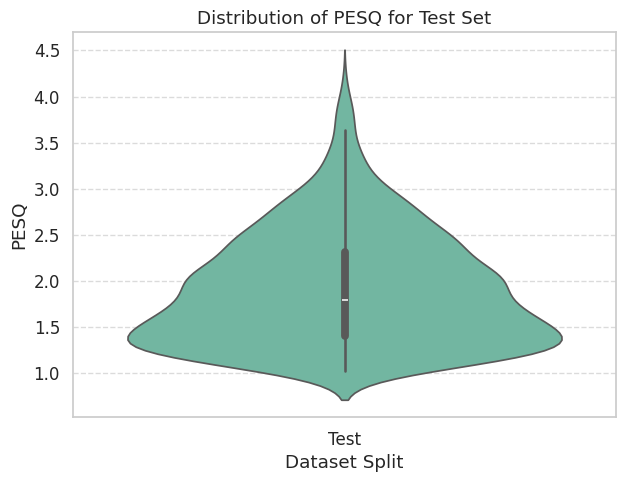

Saved: metric_plots_test_only/plot_PESQ.png
Plotting STOI...


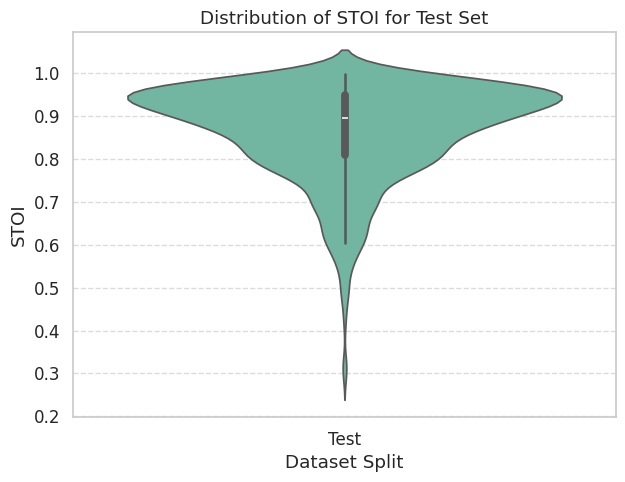

Saved: metric_plots_test_only/plot_STOI.png
Plotting SI-SDR (dB)...


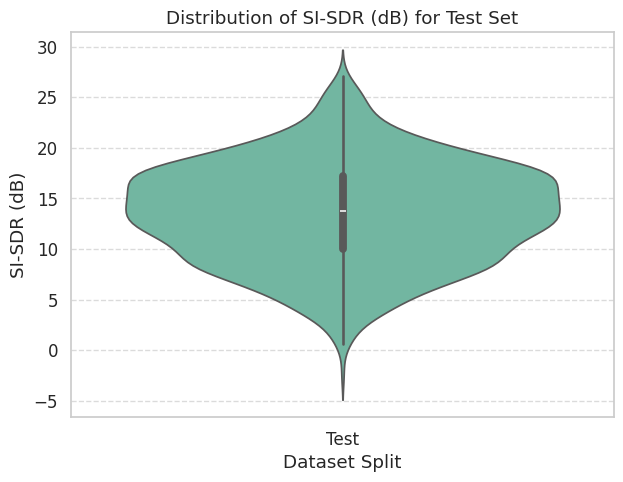

Saved: metric_plots_test_only/plot_SI_SDR_dB.png


In [15]:
def build_metric_df(metric_list, metric_name, split_name):
    return pd.DataFrame({
        "Score": metric_list,
        "Split": [split_name] * len(metric_list),
        "Metric": metric_name
    })

df_pesq  = build_metric_df(test_ps, "PESQ", "Test")
df_stoi  = build_metric_df(test_st, "STOI", "Test")
df_sisdr = build_metric_df(test_sd, "SI-SDR (dB)", "Test")

full_df = pd.concat([df_pesq, df_stoi, df_sisdr], ignore_index=True)


# --- Plotting Separately ---
sns.set(style="whitegrid", font_scale=1.1)
dataset_order = ['Test'] # Only 'Test' split
palette = "Set2"

metric_names = full_df['Metric'].unique()

# Create a directory to save plots (optional)
output_dir = "metric_plots_test_only"
os.makedirs(output_dir, exist_ok=True)

print(f"--- Generating and saving separate plots to '{output_dir}' directory ---")

for metric_name in metric_names:
    print(f"Plotting {metric_name}...")

    # Filter the DataFrame for the current metric
    metric_df = full_df[full_df['Metric'] == metric_name]

    # Create a new figure and axes for each plot
    fig, ax = plt.subplots(figsize=(7, 5))

    # Create the violin plot on the current axes
    sns.violinplot(
        data=metric_df,
        x="Split",
        y="Score",
        hue="Split",
        order=dataset_order,
        palette=palette,
        inner="box",
        ax=ax
    )

    # --- Customization for the current plot ---
    ax.set_title(f"Distribution of {metric_name} for Test Set")
    ax.set_xlabel("Dataset Split")
    ax.set_ylabel(metric_name) # Use metric name as y-label
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Save the current figure ---
    safe_metric_name = metric_name.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '').replace('-', '_')
    filename = os.path.join(output_dir, f"plot_{safe_metric_name}.png")

    plt.show()

    try:
        fig.show()
        # fig.savefig(filename, bbox_inches='tight', dpi=150)
        print(f"Saved: {filename}")
    except Exception:
        print(f"Failed to save: {filename}")

    # --- Close the current figure to free up memory ---
    plt.close(fig)

Visualizing and listening to test set example 868:


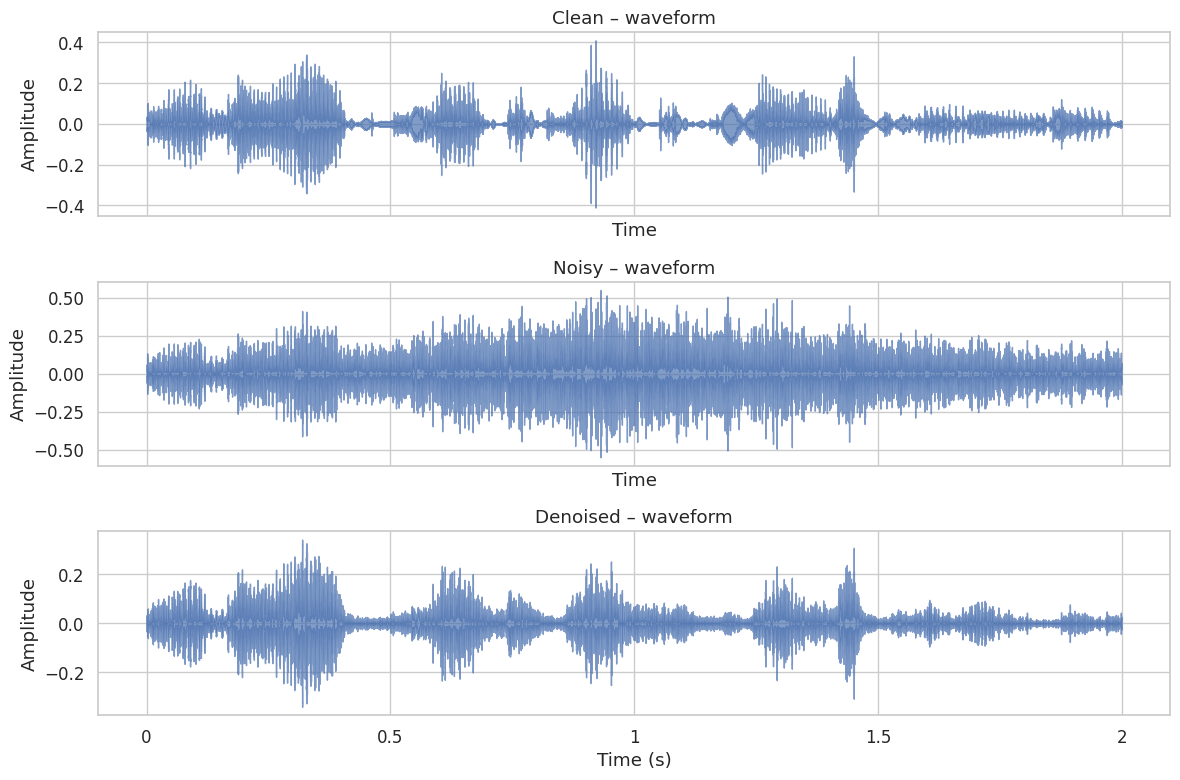

<ipython-input-17-1acfd22c75fc>:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


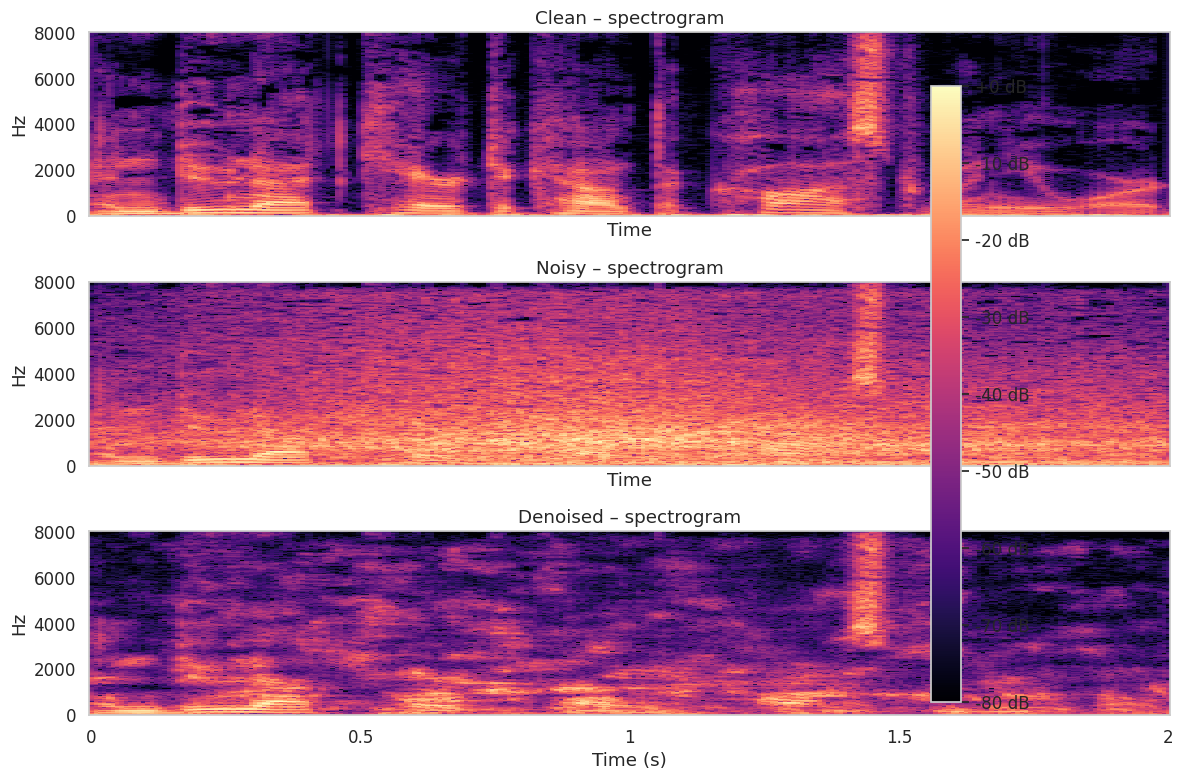

▶ Clean


▶ Noisy


▶ Denoised


In [17]:
import matplotlib.pyplot as plt
from IPython.display import Audio, display  # Import Audio


def visualize_and_listen(dataset, idx, cfg, net, device, gmin, gmax):
    row = dataset.meta.iloc[idx]
    clean_wav, _ = librosa.load(row.clean, sr=cfg.sr)
    noisy_wav, _ = librosa.load(row.noisy, sr=cfg.sr)

    with torch.no_grad():
        nm = dataset[idx]["nm"].unsqueeze(0).to(device)
        out = net(nm).cpu()[0, 0].numpy()

    denoised_wav = nm2wav(out, np.angle(librosa.stft(noisy_wav, n_fft=cfg.n_fft, hop_length=cfg.hop, win_length=cfg.win)), cfg, gmin, gmax)

    # 1️⃣ Three waveforms in one figure
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, y, title in zip(axes, [clean_wav, noisy_wav, denoised_wav], ["Clean", "Noisy", "Denoised"]):
        librosa.display.waveshow(y, sr=cfg.sr, ax=ax, alpha=0.7)
        ax.set(title=f"{title} – waveform", ylabel="Amplitude")
    axes[-1].set(xlabel="Time (s)")
    fig.tight_layout()
    plt.show()

    # 2️⃣ Three spectrograms in one figure
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=True)
    for ax, y, title in zip(axes, [clean_wav, noisy_wav, denoised_wav], ["Clean", "Noisy", "Denoised"]):
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=512, hop_length=128)), ref=np.max)
        img = librosa.display.specshow(D, sr=cfg.sr, hop_length=128, x_axis="time", y_axis="linear", ax=ax)
        ax.set(title=f"{title} – spectrogram")
    fig.colorbar(img, ax=axes, format="%+2.0f dB")
    axes[-1].set(xlabel="Time (s)")
    fig.tight_layout()
    plt.show()

    print("▶ Clean")
    display(Audio(clean_wav, rate=cfg.sr))
    print("▶ Noisy")
    display(Audio(noisy_wav, rate=cfg.sr))
    print("▶ Denoised")
    display(Audio(denoised_wav, rate=cfg.sr))


# Pick a random index from the test set and visualize
random_index = np.random.randint(len(test_ds))
print(f"Visualizing and listening to test set example {random_index}:")
visualize_and_listen(test_ds, random_index, Cfg, net, device, test_ds.gmin, test_ds.gmax)


Visualizing and listening to test set example 207:


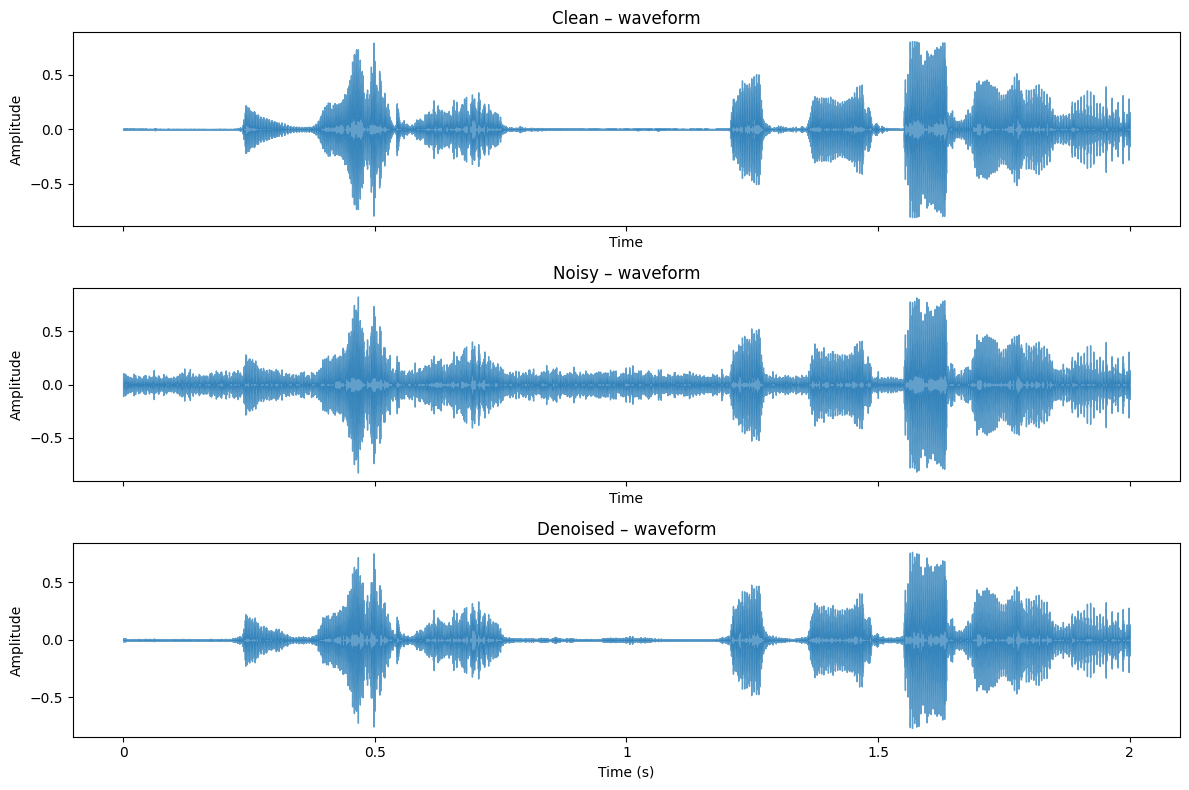

<ipython-input-27-1acfd22c75fc>:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


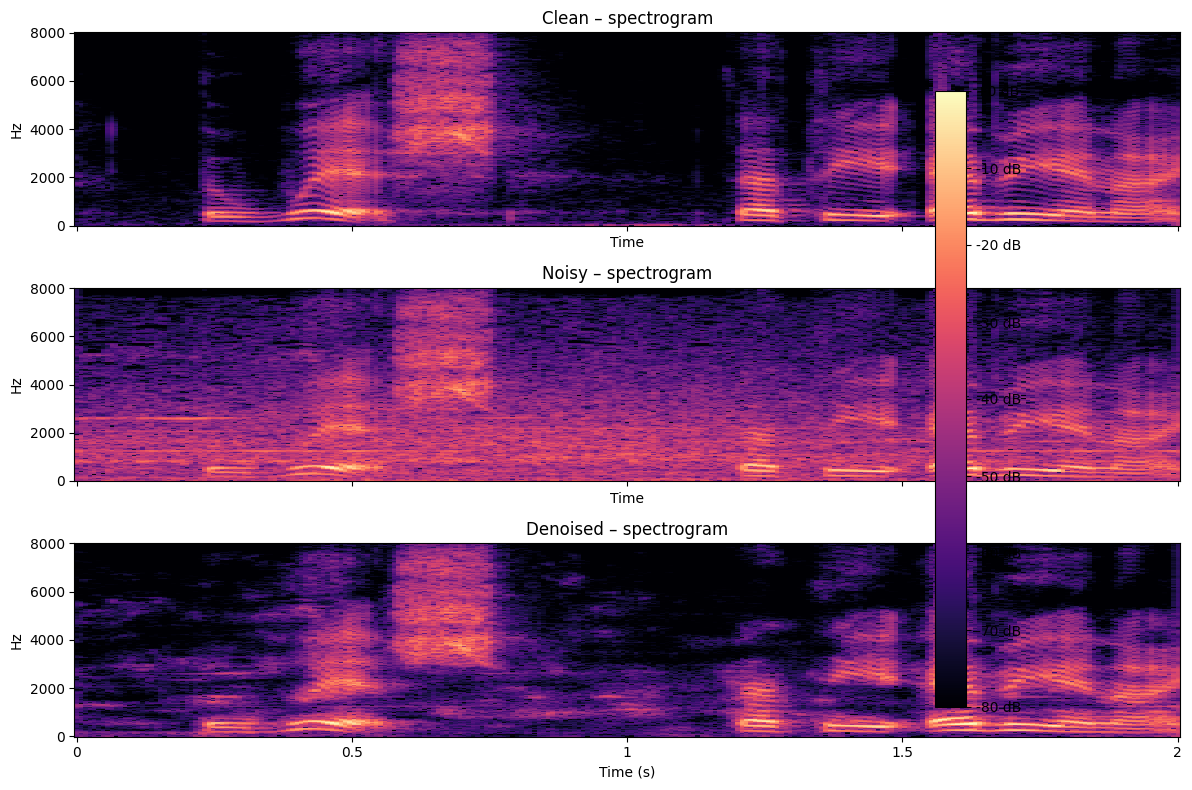

▶ Clean


▶ Noisy


▶ Denoised


In [ ]:

# Pick a random index from the test set and visualize
random_index = np.random.randint(len(test_ds))
print(f"Visualizing and listening to test set example {random_index}:")
visualize_and_listen(test_ds, random_index, Cfg, net, device, test_ds.gmin, test_ds.gmax)


## Experiment with Real World Data
Now lets look into few real world sample.

In [45]:
def _denoise_segment(
    model: torch.nn.Module,
    params: dict,
    seg: np.ndarray,
    device = "cuda"
) -> np.ndarray:
    """Run one 2‑second segment (exactly 32000 samples) through the U‑Net."""
    gmin, gmax = params["gmin"], params["gmax"]
    # STFT → log‑mag → [0, 1]
    D = librosa.stft(seg,
                     n_fft=params["n_fft"],
                     hop_length=params["hop_length"],
                     win_length=params["win_length"])
    phase = np.angle(D)
    logmag = np.log1p(np.abs(D))
    logmag_norm = (logmag - gmin) / (1e-8 + (gmax - gmin))

    inp = torch.from_numpy(logmag_norm)[None, None].float().to(device)
    with torch.no_grad():
        pred_norm = model(inp)[0, 0].cpu().numpy()

    pred_logmag = pred_norm * (gmax - gmin) + gmin
    mag = np.expm1(pred_logmag)
    stft_pred = mag * np.exp(1j * phase)
    return librosa.istft(stft_pred,
                         hop_length=params["hop_length"],
                         win_length=params["win_length"],
                         length=len(seg))


def denoise_long_audio(
    model: torch.nn.Module,
    params: dict,
    noisy_path: str,
    out_path: str = None,
    seg_sec: float = 2.0,
    overlap: float = 0.5,
    display_audio: bool = True,
    display_waveform: bool = True
):
    """
    Denoise an audio file of any length using 2‑s overlap‑add.

    Returns (denoised_waveform, sample_rate).  Optionally writes to out_path.
    """
    sr = params["sr"]
    y, sr_loaded = librosa.load(noisy_path, sr=sr)
    if sr_loaded != sr:
        raise RuntimeError(f"Sample‑rate mismatch: loaded {sr_loaded}, expected {sr}")

    seg_len = int(seg_sec * sr)
    hop_len = int(seg_len * (1 - overlap))
    win = np.hanning(seg_len).astype(np.float32)

    # padded length so last segment is complete
    pad = (-(len(y) - seg_len) % hop_len) % hop_len
    y_padded = np.pad(y, (0, pad), mode="constant")

    out = np.zeros_like(y_padded, dtype=np.float32)
    acc = np.zeros_like(y_padded, dtype=np.float32)

    for start in range(0, len(y_padded) - seg_len + 1, hop_len):
        seg = y_padded[start:start + seg_len]
        den = _denoise_segment(model, params, seg)

        out[start:start + seg_len] += den * win
        acc[start:start + seg_len] += win

    # avoid division by tiny numbers
    eps = 1e-8
    denoised = out[:len(y_padded)] / (acc + eps)
    denoised = denoised[:len(y)]          # trim the padding

    if out_path:
        sf.write(out_path, denoised, sr)
        print(f"✓ Denoised file saved → {out_path}")

    if display_audio:
        print("▶ Original")
        display(Audio(y, rate=sr))
        print("▶ Denoised")
        display(Audio(denoised, rate=sr))

    if display_waveform:
        name = os.path.basename(noisy_path).replace(".wav", "")
        fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        librosa.display.waveshow(y, sr=sr, ax=axes[0], alpha=0.7)
        axes[0].set(title=f"Original – waveform from sample - {name}", ylabel="Amplitude")
        librosa.display.waveshow(denoised, sr=sr, ax=axes[1], alpha=0.7)
        axes[1].set(title=f"Denoised – waveform from sample - {name}", ylabel="Amplitude")
        fig.tight_layout()
        plt.show()

    return denoised, sr

def compute_snr(clean, denoised):
    noise = clean - denoised
    return 10 * np.log10(np.mean(clean**2) / (np.mean(noise**2) + 1e-10))

def convert_to_16khz_wav(input_path, output_path):
    y, sr = librosa.load(input_path, sr=16000)
    sf.write(output_path, y, sr)
    print(f"✓ Converted {input_path} to {output_path} at 16kHz")


In [43]:
sample_1 = "custom-audio-busy-road-1.wav"

In [21]:
params = {
    "sr": 16000,
    "n_fft": 512,
    "hop_length": 128,
    "win_length": 512,
    "gmin": 0.0,
    "gmax": 5.6
}

✓ Denoised file saved → custom-audio-1-denoised.wav
▶ Original


▶ Denoised


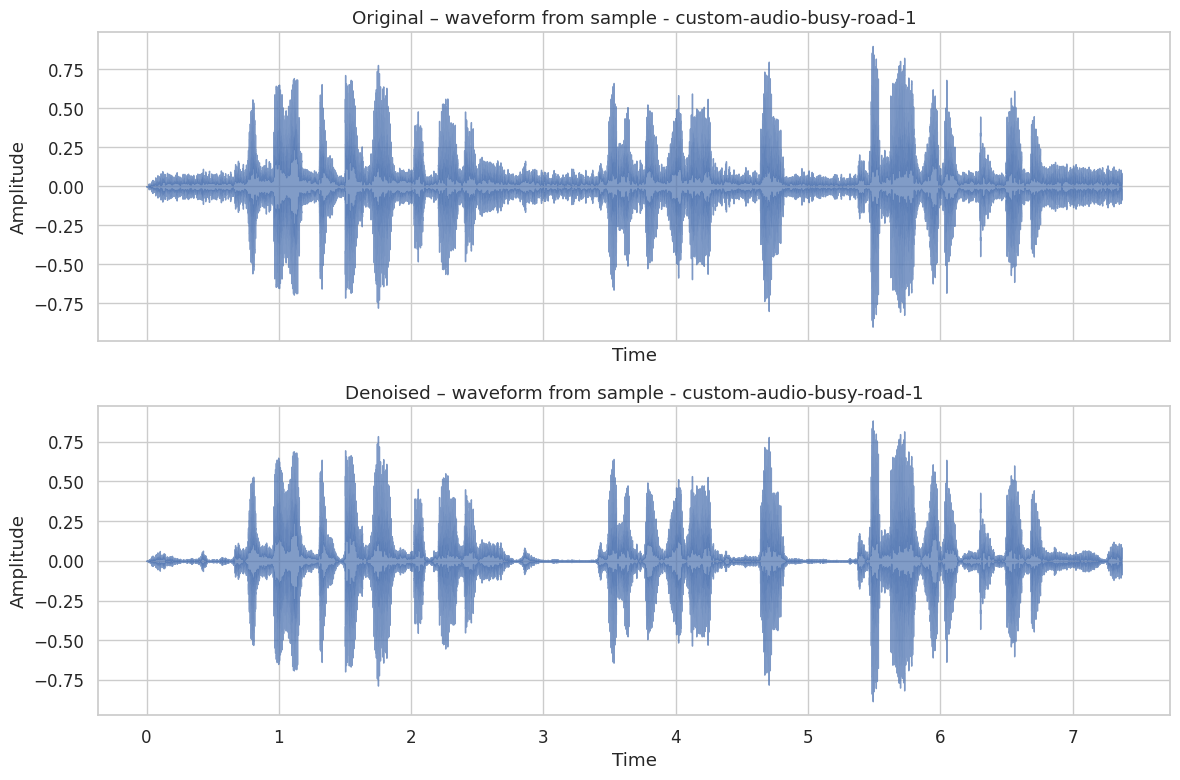

In [46]:
denoise_audio, sr =  denoise_long_audio(
    net,
    params,
    sample_1,
    seg_sec=2.0,
    overlap=0.5,
    out_path="custom-audio-1-denoised.wav"
)

In [52]:
sample_2 = "custom-audio-fan-noise-1.wav"

✓ Denoised file saved → desnoised-sample-2.wav
▶ Original


▶ Denoised


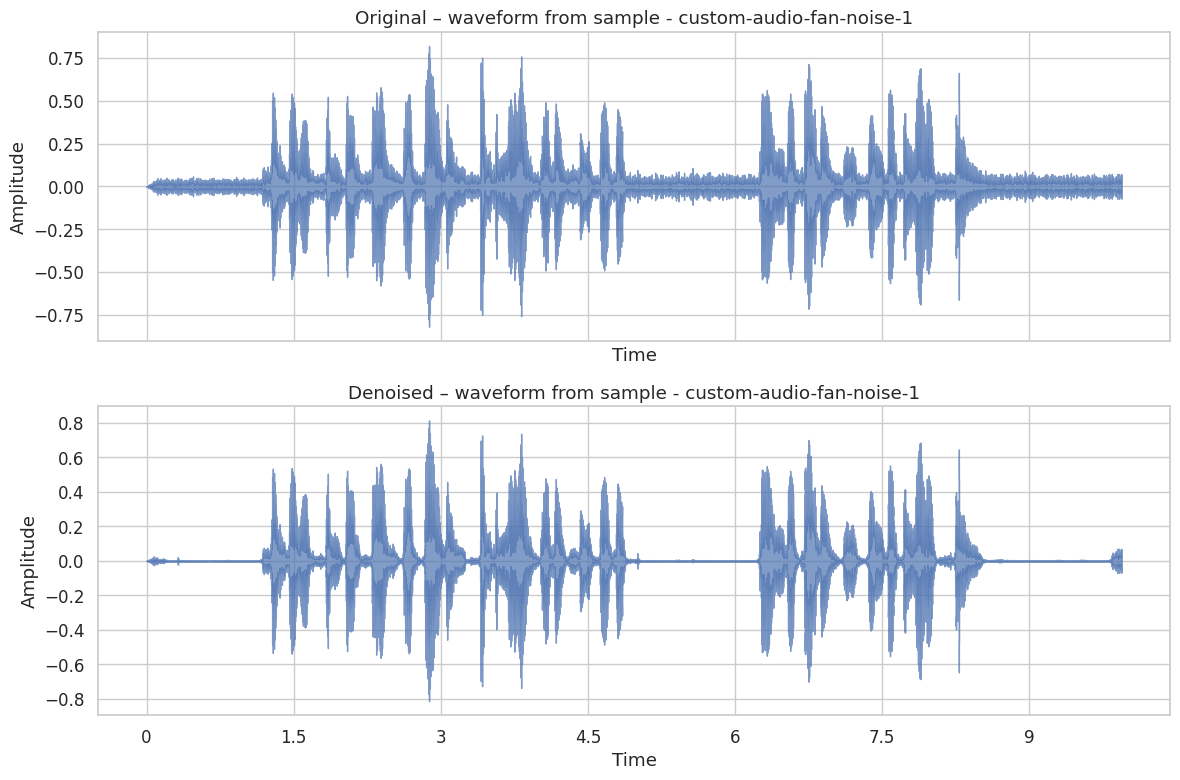

In [53]:
denoise_audio, sr =  denoise_long_audio(
    net,
    params,
    sample_2,
    seg_sec=2.0,
    overlap=0.5,
    out_path="desnoised-sample-2.wav"
)